# 7. Model Explainability (SHAP Analysis)

## Objective

Interpret model predictions using SHAP to understand key churn drivers.

In [1]:
!pip install shap

   ---------------------------------------- 0.0/549.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/549.1 kB ? eta -:--:--
   ------------------- -------------------- 262.1/549.1 kB ? eta -:--:--
   ---------------------------------------- 549.1/549.1 kB 1.3 MB/s  0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.8 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.8 MB 1.9 MB/s eta 0:00:02
   ----------- ---------------------------- 0.8/2.8 MB 1.9 MB/s eta 0:00:02
   ------------------- -------------------- 1.3/2.8 MB 1.9 MB/s eta 0:00:01
   ---------------------- ----------------- 1.6/2.8 MB 1.8 MB/s eta 0:00:01
   ------------------------------ --------- 2.1/2.8 MB 1.8 MB/s eta 0:00:01
   ---------------------------------- ----- 2.4/2.8 MB 1.9 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 1.8 MB/s  0:00:01
   --------------------------------------


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Approach

SHAP (SHapley Additive exPlanations) is applied to:

- Quantify global feature importance
- Understand directionality of feature impact
- Validate behavioral assumptions


In [3]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import shap
import matplotlib.pyplot as plt

from src.config import PROCESSED_DATA_PATH
from src.modeling import prepare_data, train_xgboost

In [10]:
# Loading Modeling Dataset
path = os.path.join(PROCESSED_DATA_PATH, "modeling_dataset.csv")
df = pd.read_csv(path)

X = df.drop(columns=["CustomerID", "Churn"]).fillna(0)
y = df["Churn"]

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
# Training XGBoost
model = train_xgboost(X_train_scaled, y_train)

In [12]:
# Creating SHAP explainer
import pandas as pd

X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_df)

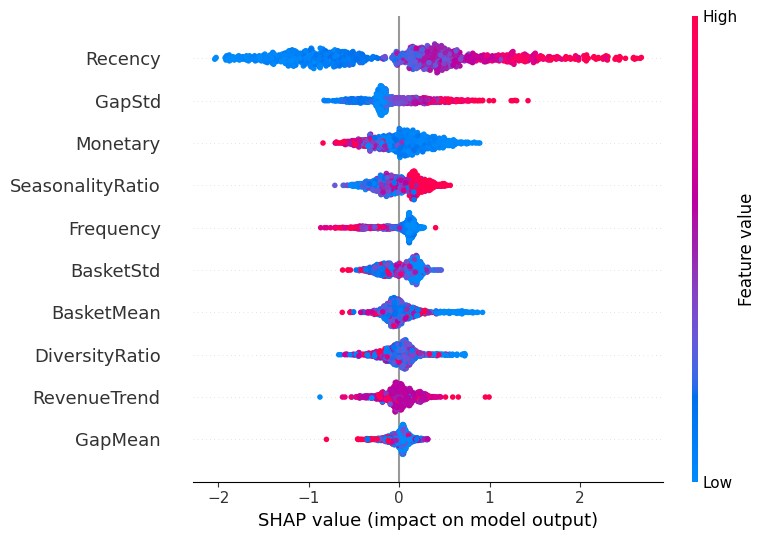

In [13]:
shap.summary_plot(shap_values, X_test_df)

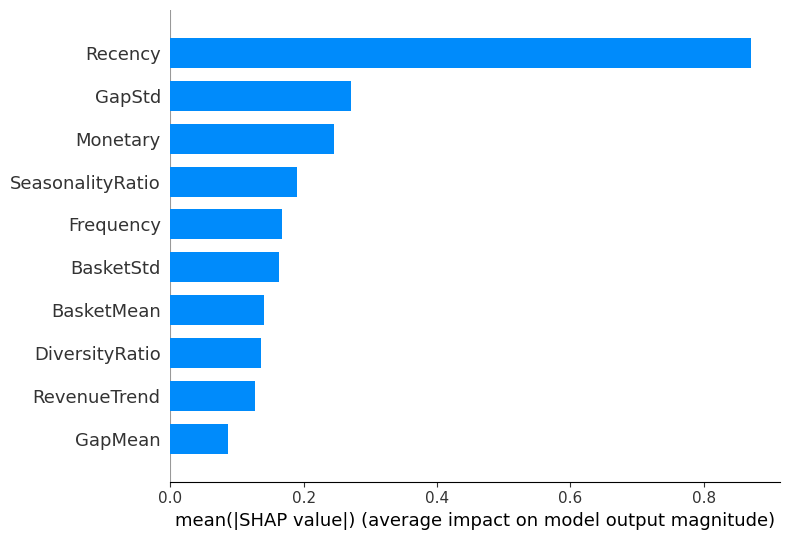

In [14]:
shap.summary_plot(shap_values, X_test_df, plot_type="bar")

## Key Findings

Top churn drivers:
- Recency (strongest)
- Interpurchase volatility
- Monetary value
- Frequency
- Seasonality

## Business Interpretation

Customers with:
- Long inactivity
- Unstable buying intervals
- Declining spending patterns

are significantly more likely to churn.

Explainability ensures model transparency and trust.